# Zimbabwe MICS preprocessing — ADM1 version with climate medians

This notebook mirrors the structure of the Nigeria MICS preprocessing notebook, while keeping the Zimbabwe-specific elements from the previous Zimbabwe preprocessing notebook:

- Zimbabwe MICS SPSS paths
- Zimbabwe-specific education mapping
- ADM1 attachment from the Zimbabwe admin boundary file
- ADM1 entropy from raster zonal means
- ADM1 RWI from point aggregation
- ADM1 climate medians from:

`/data/shared/fsibilla/DATA_PROCESSING/zwe_mics/climate_medians.csv`

Spatial resolution is intentionally **ADM1 only** for MICS, as in the Nigeria notebook.

In [1]:
from pathlib import Path
import re
import unicodedata
import warnings

import numpy as np
import pandas as pd
import geopandas as gpd

from shapely import wkt
from shapely.geometry.base import BaseGeometry

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 150)
pd.set_option("display.width", 220)
pd.set_option("display.max_rows", 120)

In [2]:
# Paths
BASE_MICS = Path("/data/shared/fsibilla/wfp-da4hd/DATA/in/zwe/Zimbabwe MICS6 SPSS Datasets")
BASE_ZWE_IN = Path("/data/shared/fsibilla/wfp-da4hd/DATA/in/zwe")
BASE_ZWE_OUT = Path("/data/shared/fsibilla/wfp-da4hd/DATA/out/zwe")
BASE_OUT = Path("/data/shared/fsibilla/DATA_PROCESSING/zwe_mics")

HH_PATH = BASE_MICS / "hh.sav"
HL_PATH = BASE_MICS / "hl.sav"
ADM1_BOUNDARIES_PATH = BASE_ZWE_IN / "zwe_admin_boundaries" / "zwe_admin1_simplified.json"
ENTROPY_TIF_PATH = BASE_ZWE_IN / "entropy_mod_4h_moto.tif"
RWI_CSV_PATH = BASE_ZWE_IN / "ZWE_relative_wealth_index.csv"
CLIMATE_MEDIANS_PATH = BASE_OUT / "climate_medians.csv"

# Main output, mirroring the Nigeria notebook convention.
FINAL_CSV_PATH = BASE_OUT / "full.csv"

# Optional compatibility output used in the older Zimbabwe notebook.
LEGACY_FINAL_CSV_PATH = Path("/data/shared/fsibilla/clean_code/Q1/experiments/zwe_mics/full.csv")

print("Household SPSS exists:", HH_PATH.exists(), HH_PATH)
print("Household-list SPSS exists:", HL_PATH.exists(), HL_PATH)
print("ADM1 boundaries exist:", ADM1_BOUNDARIES_PATH.exists(), ADM1_BOUNDARIES_PATH)
print("Entropy raster exists:", ENTROPY_TIF_PATH.exists(), ENTROPY_TIF_PATH)
print("RWI CSV exists:", RWI_CSV_PATH.exists(), RWI_CSV_PATH)
print("Climate medians exists:", CLIMATE_MEDIANS_PATH.exists(), CLIMATE_MEDIANS_PATH)
print("Final output path:", FINAL_CSV_PATH)

Household SPSS exists: True /data/shared/fsibilla/wfp-da4hd/DATA/in/zwe/Zimbabwe MICS6 SPSS Datasets/hh.sav
Household-list SPSS exists: True /data/shared/fsibilla/wfp-da4hd/DATA/in/zwe/Zimbabwe MICS6 SPSS Datasets/hl.sav
ADM1 boundaries exist: True /data/shared/fsibilla/wfp-da4hd/DATA/in/zwe/zwe_admin_boundaries/zwe_admin1_simplified.json
Entropy raster exists: True /data/shared/fsibilla/wfp-da4hd/DATA/in/zwe/entropy_mod_4h_moto.tif
RWI CSV exists: True /data/shared/fsibilla/wfp-da4hd/DATA/in/zwe/ZWE_relative_wealth_index.csv
Climate medians exists: True /data/shared/fsibilla/DATA_PROCESSING/zwe_mics/climate_medians.csv
Final output path: /data/shared/fsibilla/DATA_PROCESSING/zwe_mics/full.csv


## Helper functions

In [3]:
def normalize_name(x):
    """
    Normalize administrative names for robust matching.
    """
    if pd.isna(x):
        return ""
    s = str(x).strip().lower()
    s = unicodedata.normalize("NFKD", s)
    s = "".join(ch for ch in s if not unicodedata.combining(ch))
    s = s.replace("&", " and ").replace("-", " ")
    s = re.sub(r"[^a-z0-9]+", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s


# Zimbabwe-specific aliases can be extended here if diagnostics show unmatched names.
ADM1_ALIASES = {
    "bulawayo metropolitan": "bulawayo",
    "harare metropolitan": "harare",
    "manicaland province": "manicaland",
    "mashonaland central province": "mashonaland central",
    "mashonaland east province": "mashonaland east",
    "mashonaland west province": "mashonaland west",
    "masvingo province": "masvingo",
    "matabeleland north province": "matabeleland north",
    "matabeleland south province": "matabeleland south",
    "midlands province": "midlands",
}


def adm1_key(x):
    key = normalize_name(x)
    return ADM1_ALIASES.get(key, key)


def clean_code(x):
    """
    Make admin codes comparable.
    """
    if pd.isna(x):
        return ""
    s = str(x).strip()
    s = re.sub(r"\.0$", "", s)
    s = s.replace(" ", "")
    return s.upper()


def parse_geometry(x):
    """
    Convert WKT text to shapely geometry. If already geometry, keep it.
    """
    if isinstance(x, BaseGeometry):
        return x
    if pd.isna(x):
        return None
    if isinstance(x, str):
        try:
            return wkt.loads(x)
        except Exception:
            return None
    return None


def show_shape(name, data):
    print(f"{name}: {data.shape[0]} rows, {data.shape[1]} columns")


def make_household_id(df, hh1_col="HH1", hh2_col="HH2"):
    """
    Stable household id from cluster and household number.
    Kept as string to avoid accidental collisions from simple concatenation.
    """
    hh1 = pd.to_numeric(df[hh1_col], errors="coerce").astype("Int64").astype(str)
    hh2 = pd.to_numeric(df[hh2_col], errors="coerce").astype("Int64").astype(str)
    return hh1 + "_" + hh2


def first_existing_col(columns, candidates, required=True, label="column"):
    for c in candidates:
        if c in columns:
            return c
    if required:
        raise KeyError(f"Could not find {label}. Tried: {candidates}")
    return None

## Load and preprocess MICS household data

In [4]:
df_hh_raw = pd.read_spss(HH_PATH)

hh_cols = ["HH6", "HH7", "HH1", "HH2", "HH46", "HH48", "HC3", "WS4"]
df_hh = df_hh_raw[hh_cols].copy()

show_shape("Raw household data", df_hh)
display(df_hh.head())

Raw household data: 12012 rows, 8 columns


,HH6,HH7,HH1,HH2,HH46,HH48,HC3,WS4
0,URBAN,Bulawayo,1.0,1.0,COMPLETED,1.0,1.0,NaN
1,URBAN,Bulawayo,1.0,2.0,COMPLETED,2.0,1.0,NaN
2,URBAN,Bulawayo,1.0,3.0,COMPLETED,5.0,3.0,NaN
3,URBAN,Bulawayo,1.0,4.0,COMPLETED,5.0,2.0,NaN
4,URBAN,Bulawayo,1.0,5.0,NO HOUSEHOLD MEMBER AT HOME OR NO COMPETENT RE...,NaN,NaN,NaN


In [5]:
# Keep completed interviews only
completion = df_hh["HH46"].astype(str).str.upper().str.strip()
df_hh = df_hh[completion.eq("COMPLETED")].copy()

# Household id
df_hh["id"] = make_household_id(df_hh, "HH1", "HH2")

# Rename columns
df_hh = df_hh.rename(columns={
    "HH6": "sector",
    "HH7": "survey_adm1name",
    "HH48": "hh_size",
    "HC3": "rooms",
    "WS4": "water_source",
    "HH1": "psu",
})

# Keep useful household columns
df_hh = df_hh[["sector", "survey_adm1name", "id", "hh_size", "rooms", "water_source", "psu"]].copy()

# Numeric conversion
num_cols = ["hh_size", "rooms", "water_source", "psu"]
df_hh[num_cols] = df_hh[num_cols].apply(pd.to_numeric, errors="coerce")

# If there are duplicate household ids, aggregate numeric columns and keep first categorical fields.
agg_dict = {
    "sector": "first",
    "survey_adm1name": "first",
    "hh_size": "mean",
    "rooms": "mean",
    "water_source": "mean",
    "psu": "first",
}

df_hh = (
    df_hh
    .sort_values("id")
    .groupby("id", as_index=False)
    .agg(agg_dict)
)

show_shape("Household data after filtering/aggregation", df_hh)
print("Unique survey ADM1 names:", df_hh["survey_adm1name"].nunique())
display(df_hh.head())

Household data after filtering/aggregation: 11091 rows, 7 columns
Unique survey ADM1 names: 10


,id,sector,survey_adm1name,hh_size,rooms,water_source,psu
0,100_1,RURAL,Mashonaland Central,4.0,3.0,1.0,100.0
1,100_10,RURAL,Mashonaland Central,4.0,1.0,10.0,100.0
2,100_11,RURAL,Mashonaland Central,8.0,5.0,10.0,100.0
3,100_12,RURAL,Mashonaland Central,4.0,1.0,20.0,100.0
4,100_13,RURAL,Mashonaland Central,4.0,1.0,20.0,100.0


## Load and preprocess MICS household-list data

In [6]:
df_hl_raw = pd.read_spss(HL_PATH)

hl_cols = ["HL6", "HH6", "HH7", "HH1", "HH2", "ED5A", "wscore"]
# Zimbabwe file may or may not include wscoreMICS. Keep it if present.
if "wscoreMICS" in df_hl_raw.columns:
    hl_cols.append("wscoreMICS")

df_hl = df_hl_raw[hl_cols].copy()

show_shape("Raw household-list data", df_hl)
display(df_hl.head())

Raw household-list data: 44472 rows, 7 columns


,HL6,HH6,HH7,HH1,HH2,ED5A,wscore
0,52.0,URBAN,Bulawayo,1.0,1.0,LOWER SECONDARY,1.829142
1,21.0,URBAN,Bulawayo,1.0,2.0,TERTIARY - HIGHER NATIONAL DIPLOMA / BACHELOR ...,1.588014
2,24.0,URBAN,Bulawayo,1.0,2.0,TERTIARY - HIGHER NATIONAL DIPLOMA / BACHELOR ...,1.588014
3,24.0,URBAN,Bulawayo,1.0,3.0,LOWER SECONDARY,1.664856
4,5.0,URBAN,Bulawayo,1.0,3.0,ECE,1.664856


In [7]:
df_hl["age"] = pd.to_numeric(df_hl["HL6"], errors="coerce")
is_adult = df_hl["age"].ge(17)

# Zimbabwe-specific education mapping from the previous Zimbabwe preprocessing notebook.
education_mapping = {
    "DK": 0.00,
    "NO RESPONSE": 0.00,
    "SYSMISS": 0.00,
    None: 0.00,
    float("nan"): 0.00,

    "ECE": 0.10,
    "PRIMARY": 0.30,
    "LOWER SECONDARY": 0.45,
    "UPPER SECONDARY": 0.60,

    "VOCATIONAL - NATION FOUNDATION CERTIFICATE": 0.65,
    "VOCATIONAL - CERTIFICATE": 0.70,
    "VOCATIONAL - APPRENTICESHIP / TEACHER COLLEGE": 0.75,

    "TERTIARY - SHORT CYCLE": 0.82,
    "TERTIARY - HIGHER NATIONAL DIPLOMA / BACHELOR / BACHELOR?S HONOUR": 0.90,
    "TERTIARY - MASTER / DOCTORATE MEDICAL COURSES": 0.97,
    "DOCTORATE": 1.00,
}

df_hl["education_numeric"] = df_hl["ED5A"].map(education_mapping).fillna(0)
df_hl["id"] = make_household_id(df_hl, "HH1", "HH2")

df_hl["wscore"] = pd.to_numeric(df_hl["wscore"], errors="coerce")
if "wscoreMICS" in df_hl.columns:
    df_hl["wscoreMICS"] = pd.to_numeric(df_hl["wscoreMICS"], errors="coerce")

adult_mean_edu = (
    df_hl.loc[is_adult]
         .groupby("id")["education_numeric"]
         .mean()
         .rename("avg_adult_education")
         .reset_index()
)

score_cols = [c for c in ["wscore", "wscoreMICS"] if c in df_hl.columns]
hh_scores = (
    df_hl.groupby("id", as_index=False)[score_cols]
         .mean()
)

df_household_scores = hh_scores.merge(adult_mean_edu, on="id", how="left")

show_shape("Household score/education data", df_household_scores)
display(df_household_scores.head())

Household score/education data: 11091 rows, 3 columns


,id,wscore,avg_adult_education
0,100_1,-0.440231,0.450
1,100_10,0.244739,0.450
2,100_11,-0.260945,0.100
3,100_12,-0.541268,0.450
4,100_13,-0.859621,0.375


## Merge household-level MICS variables

In [8]:
before = len(df_hh)

df = df_hh.merge(df_household_scores, on="id", how="inner")

after = len(df)
print("Rows before household/person merge:", before)
print("Rows after household/person merge:", after)

# Derived variables
df["space_per_person"] = df["rooms"] / df["hh_size"].replace(0, np.nan)
df["adm1_key"] = df["survey_adm1name"].map(adm1_key)

show_shape("Merged MICS household dataset", df)
display(df.head())

Rows before household/person merge: 11091
Rows after household/person merge: 11091
Merged MICS household dataset: 11091 rows, 11 columns


,id,sector,survey_adm1name,hh_size,rooms,water_source,psu,wscore,avg_adult_education,space_per_person,adm1_key
0,100_1,RURAL,Mashonaland Central,4.0,3.0,1.0,100.0,-0.440231,0.450,0.750,mashonaland central
1,100_10,RURAL,Mashonaland Central,4.0,1.0,10.0,100.0,0.244739,0.450,0.250,mashonaland central
2,100_11,RURAL,Mashonaland Central,8.0,5.0,10.0,100.0,-0.260945,0.100,0.625,mashonaland central
3,100_12,RURAL,Mashonaland Central,4.0,1.0,20.0,100.0,-0.541268,0.450,0.250,mashonaland central
4,100_13,RURAL,Mashonaland Central,4.0,1.0,20.0,100.0,-0.859621,0.375,0.250,mashonaland central


## Merge ADM1 geovariables/admin data

Zimbabwe does not use the same complete ADM1 CSV structure as the Nigeria notebook. Here, ADM1 names/codes/geometries are attached from the Zimbabwe ADM1 boundary file, preserving the previous Zimbabwe-specific approach.

In [9]:
def load_adm1_boundaries(path):
    shp = gpd.read_file(path)
    print("ADM1 boundary columns:")
    print(shp.columns.tolist())

    name_col = first_existing_col(
        shp.columns,
        ["adm1_name", "ADM1_EN", "ADM1_NAME", "admin1Name", "adm1Name", "NAME", "Region", "REGION", "province", "Province"],
        label="ADM1 name column in boundary file",
    )
    code_col = first_existing_col(
        shp.columns,
        ["GID_1", "ID_1", "ADM1_CODE", "ADM1_PCODE", "PCODE", "pcode", "CODE"],
        required=False,
        label="ADM1 code column in boundary file",
    )

    out = shp.copy()
    out["adm1name"] = out[name_col].astype(str)
    out["adm1_key"] = out["adm1name"].map(adm1_key)
    out["adm1code"] = out[code_col].apply(clean_code) if code_col is not None else ""
    out = out.rename(columns={"geometry": "adm1geometry"})

    out = out[["adm1_key", "adm1name", "adm1code", "adm1geometry"]].drop_duplicates(subset=["adm1_key"]).copy()
    out = gpd.GeoDataFrame(out, geometry="adm1geometry", crs=shp.crs)

    return out


adms_adm1 = load_adm1_boundaries(ADM1_BOUNDARIES_PATH)

show_shape("ADM1 boundary lookup", adms_adm1)
display(adms_adm1.head())

ADM1 boundary columns:
['adm1_name', 'adm1_name1', 'adm1_name2', 'adm1_name3', 'adm1_pcode', 'adm0_name', 'adm0_name1', 'adm0_name2', 'adm0_name3', 'adm0_pcode', 'valid_on', 'valid_to', 'area_sqkm', 'version', 'lang', 'lang1', 'lang2', 'lang3', 'adm1_ref_name', 'center_lat', 'center_lon', 'geometry']
ADM1 boundary lookup: 10 rows, 4 columns


,adm1_key,adm1name,adm1code,adm1geometry
0,bulawayo,Bulawayo,,"POLYGON ((28.60532 -20.22744, 28.62704 -20.232..."
1,harare,Harare,,"POLYGON ((30.89451 -17.94903, 30.98987 -17.991..."
2,manicaland,Manicaland,,"POLYGON ((32.44497 -21.30887, 32.47614 -21.310..."
3,mashonaland central,Mashonaland Central,,"POLYGON ((32.7568 -16.70218, 32.70233 -16.6751..."
4,mashonaland east,Mashonaland East,,"POLYGON ((32.99432 -17.24566, 32.98967 -17.184..."


In [10]:
before = len(df)

df = df.merge(
    adms_adm1,
    on="adm1_key",
    how="left",
    validate="m:1",
    indicator="admin_merge_status",
)

after = len(df)
print("Rows before admin merge:", before)
print("Rows after admin merge:", after)
print("\nAdmin merge status:")
print(df["admin_merge_status"].value_counts())

unmatched_admin = (
    df.loc[df["admin_merge_status"].eq("left_only"), ["survey_adm1name", "adm1_key"]]
    .drop_duplicates()
    .sort_values("adm1_key")
)

print("\nUnmatched survey ADM1 names:", len(unmatched_admin))
display(unmatched_admin)

display(
    df[["survey_adm1name", "adm1name", "adm1code", "admin_merge_status"]]
    .drop_duplicates()
    .sort_values("adm1name")
)

Rows before admin merge: 11091
Rows after admin merge: 11091

Admin merge status:
admin_merge_status
both          11091
left_only         0
right_only        0
Name: count, dtype: int64

Unmatched survey ADM1 names: 0


,survey_adm1name,adm1_key


,survey_adm1name,adm1name,adm1code,admin_merge_status
240,Bulawayo,Bulawayo,,both
8254,Harare,Harare,,both
8519,Manicaland,Manicaland,,both
0,Mashonaland Central,Mashonaland Central,,both
980,Mashonaland East,Mashonaland East,,both
2270,Mashonaland West,Mashonaland West,,both
7012,Masvingo,Masvingo,,both
3579,Matabeleland North,Matabeleland North,,both
4668,Matabeleland South,Matabeleland South,,both
5745,Midlands,Midlands,,both


## Attach Zimbabwe ADM1 entropy and RWI

This keeps the Zimbabwe-specific logic from the earlier notebook:

- `entropy_1`: zonal mean from the Zimbabwe entropy raster over ADM1 polygons
- `rwi_1`: mean RWI from Zimbabwe point data joined to ADM1 polygons

In [11]:
# Build ADM1 polygons from the matched admin lookup.
adm1_polys = (
    adms_adm1
    .drop_duplicates(subset=["adm1_key"])
    .loc[:, ["adm1_key", "adm1name", "adm1code", "adm1geometry"]]
    .rename(columns={"adm1geometry": "geometry"})
)
adm1_polys = gpd.GeoDataFrame(adm1_polys, geometry="geometry", crs=adms_adm1.crs)

if adm1_polys.crs is None:
    raise ValueError("adm1_polys.crs is None. Check the ADM1 boundary file CRS.")


def zonal_mean_entropy(polys_gdf: gpd.GeoDataFrame, tif_path: Path) -> pd.DataFrame:
    import rasterio
    from rasterio.mask import mask
    import numpy.ma as ma

    with rasterio.open(tif_path) as src:
        if src.crs is None:
            raise ValueError("Entropy raster has no CRS.")

        g = polys_gdf.to_crs(src.crs) if polys_gdf.crs != src.crs else polys_gdf.copy()
        nodata = src.nodata

        means = []
        for geom in g.geometry:
            try:
                data, _ = mask(src, [geom], crop=True)
                arr = data[0]

                if nodata is not None:
                    arr = ma.masked_equal(arr, nodata)
                arr = ma.masked_invalid(arr)

                means.append(float(arr.mean()) if arr.count() > 0 else np.nan)
            except Exception:
                means.append(np.nan)

    out = polys_gdf[["adm1_key"]].copy()
    out["entropy_1"] = means
    return out


entropy_by_adm1 = zonal_mean_entropy(adm1_polys, ENTROPY_TIF_PATH)

if entropy_by_adm1["entropy_1"].notna().sum() == 0:
    raise RuntimeError(
        "entropy_1 is all NaN after zonal mean. "
        "This usually means the raster does not overlap polygons, CRS mismatch, or raster is empty/nodata."
    )

rwi = pd.read_csv(RWI_CSV_PATH)
needed = {"latitude", "longitude", "rwi"}
missing = needed - set(rwi.columns)
if missing:
    raise KeyError(f"RWI CSV missing columns {missing}. Found: {list(rwi.columns)}")

rwi["rwi"] = pd.to_numeric(rwi["rwi"], errors="coerce")
rwi = rwi.dropna(subset=["latitude", "longitude", "rwi"]).copy()

rwi_pts = gpd.GeoDataFrame(
    rwi,
    geometry=gpd.points_from_xy(rwi["longitude"], rwi["latitude"]),
    crs="EPSG:4326",
).to_crs(adm1_polys.crs)

joined = gpd.sjoin(rwi_pts, adm1_polys[["adm1_key", "geometry"]], how="left", predicate="within")
unmatched = joined["adm1_key"].isna().sum()

if unmatched > 0:
    joined2 = gpd.sjoin(rwi_pts, adm1_polys[["adm1_key", "geometry"]], how="left", predicate="intersects")
    joined.loc[joined["adm1_key"].isna(), "adm1_key"] = joined2.loc[joined["adm1_key"].isna(), "adm1_key"]
    unmatched2 = joined["adm1_key"].isna().sum()
    print(f"[INFO] RWI points unmatched: within={unmatched}, after intersects fallback={unmatched2}")

rwi_by_adm1 = (
    joined.dropna(subset=["adm1_key"])
          .groupby("adm1_key")["rwi"]
          .mean()
          .reset_index()
          .rename(columns={"rwi": "rwi_1"})
)

adm1_feats = entropy_by_adm1.merge(rwi_by_adm1, on="adm1_key", how="left")

show_shape("ADM1 entropy/RWI features", adm1_feats)
display(adm1_feats.head())

[INFO] RWI points unmatched: within=23, after intersects fallback=23
ADM1 entropy/RWI features: 10 rows, 3 columns


,adm1_key,entropy_1,rwi_1
0,bulawayo,1.825448,0.725974
1,harare,2.316787,0.926398
2,manicaland,0.458092,-0.382025
3,mashonaland central,0.480655,-0.389937
4,mashonaland east,0.602856,-0.354875


In [12]:
before = len(df)

df = df.merge(
    adm1_feats,
    on="adm1_key",
    how="left",
    validate="m:1",
)

after = len(df)
print("Rows before entropy/RWI merge:", before)
print("Rows after entropy/RWI merge:", after)

print("entropy_1 missing rate:", float(df["entropy_1"].isna().mean()))
print("rwi_1 missing rate:", float(df["rwi_1"].isna().mean()))

display(df[["survey_adm1name", "adm1name", "entropy_1", "rwi_1"]].drop_duplicates().head(20))

Rows before entropy/RWI merge: 11091
Rows after entropy/RWI merge: 11091
entropy_1 missing rate: 0.0
rwi_1 missing rate: 0.0


,survey_adm1name,adm1name,entropy_1,rwi_1
0,Mashonaland Central,Mashonaland Central,0.480655,-0.389937
240,Bulawayo,Bulawayo,1.825448,0.725974
980,Mashonaland East,Mashonaland East,0.602856,-0.354875
2270,Mashonaland West,Mashonaland West,0.450689,-0.418660
3579,Matabeleland North,Matabeleland North,0.303186,-0.514191
4668,Matabeleland South,Matabeleland South,0.355211,-0.526327
5745,Midlands,Midlands,0.424960,-0.475432
7012,Masvingo,Masvingo,0.514276,-0.480247
8254,Harare,Harare,2.316787,0.926398
8519,Manicaland,Manicaland,0.458092,-0.382025


## Merge ADM1 climate medians

The climate file may contain ADM1 and/or ADM2 columns. As in the Nigeria notebook, this section deliberately collapses climate data to **one ADM1 row** before merging to MICS.

In [13]:
climate_raw = pd.read_csv(CLIMATE_MEDIANS_PATH)
climate = climate_raw.copy()

show_shape("Raw climate medians", climate)
print("Climate columns:")
print(climate.columns.tolist())
display(climate.head())

Raw climate medians: 90 rows, 12 columns
Climate columns:
['adm1Name', 'adm1Code', 'adm2Name', 'adm2Code', 'rfh_avg_2', 'r3q_2', 'vim_avg_2', 'rfh_avg_1', 'r3q_1', 'vim_avg_1', 'adm1Geometry', 'adm2Geometry']


,adm1Name,adm1Code,adm2Name,adm2Code,rfh_avg_2,r3q_2,vim_avg_2,rfh_avg_1,r3q_1,vim_avg_1,adm1Geometry,adm2Geometry
0,Bulawayo,900969,Bulawayo,1010745,8.31205,95.82375,0.41220,8.31205,95.82375,0.41220,"POLYGON ((28.6053 -20.2274, 28.6083 -20.2307, ...","POLYGON ((28.6712 -20.0163, 28.6072 -19.9615, ..."
1,Harare,900970,Chitungwiza,1010758,10.20000,99.44785,0.35635,9.95000,100.74630,0.41775,"POLYGON ((30.8945 -17.949, 30.9076 -17.9642, 3...","POLYGON ((31 -17.9994, 31.0626 -18.0506, 31.11..."
2,Harare,900970,Epworth,1010760,9.65000,102.00180,0.42135,9.95000,100.74630,0.41775,"POLYGON ((30.8945 -17.949, 30.9076 -17.9642, 3...","POLYGON ((31.2031 -17.8863, 31.1303 -17.8654, ..."
3,Harare,900970,Harare,1010771,9.98495,100.26020,0.46585,9.95000,100.74630,0.41775,"POLYGON ((30.8945 -17.949, 30.9076 -17.9642, 3...","POLYGON ((31.2031 -17.8863, 31.2195 -17.8512, ..."
4,Harare,900970,Harare Rural,1010772,10.90950,102.73440,0.42625,9.95000,100.74630,0.41775,"POLYGON ((30.8945 -17.949, 30.9076 -17.9642, 3...","POLYGON ((31.1361 -17.9289, 31.125 -17.888, 31..."


In [14]:
climate_adm1_name_col = first_existing_col(
    climate.columns,
    ["adm1Name", "Name_adm1", "ADM1_NAME", "adm1name", "clim_adm1name", "adm1_name", "ADM1_EN"],
    required=False,
    label="ADM1 name column in climate file",
)
climate_adm1_code_col = first_existing_col(
    climate.columns,
    ["adm1Code", "Code_adm1", "ADM1_CODE", "adm1code", "clim_adm1code", "ADM1_PCODE", "GID_1", "ID_1", "PCODE"],
    required=False,
    label="ADM1 code column in climate file",
)
climate_adm1_geom_col = first_existing_col(
    climate.columns,
    ["adm1Geometry", "Geometry_Adm1", "geometry_adm1", "adm1geometry"],
    required=False,
    label="ADM1 geometry column in climate file",
)

print("climate_adm1_name_col:", climate_adm1_name_col)
print("climate_adm1_code_col:", climate_adm1_code_col)
print("climate_adm1_geom_col:", climate_adm1_geom_col)

if climate_adm1_name_col is not None:
    climate["clim_adm1name"] = climate[climate_adm1_name_col]
    climate["clim_adm1_key"] = climate[climate_adm1_name_col].map(adm1_key)
else:
    climate["clim_adm1name"] = np.nan
    climate["clim_adm1_key"] = ""

if climate_adm1_code_col is not None:
    climate["clim_adm1code"] = climate[climate_adm1_code_col].apply(clean_code)
else:
    climate["clim_adm1code"] = ""

if climate_adm1_geom_col is not None:
    climate["clim_adm1geometry"] = climate[climate_adm1_geom_col].apply(parse_geometry)
else:
    climate["clim_adm1geometry"] = None

# Build both possible merge keys and choose the one with the best actual overlap.
df["adm1_code_key"] = df["adm1code"].apply(clean_code) if "adm1code" in df.columns else ""
df["adm1_name_key"] = df["adm1_key"]
climate["adm1_code_key"] = climate["clim_adm1code"]
climate["adm1_name_key"] = climate["clim_adm1_key"]

code_overlap = len(set(df.loc[df["adm1_code_key"].astype(str).str.len().gt(0), "adm1_code_key"]) & set(climate.loc[climate["adm1_code_key"].astype(str).str.len().gt(0), "adm1_code_key"]))
name_overlap = len(set(df.loc[df["adm1_name_key"].astype(str).str.len().gt(0), "adm1_name_key"]) & set(climate.loc[climate["adm1_name_key"].astype(str).str.len().gt(0), "adm1_name_key"]))

if code_overlap > 0 and code_overlap >= name_overlap:
    merge_key_col = "adm1_code_key"
else:
    merge_key_col = "adm1_name_key"

print("Code-key overlap:", code_overlap)
print("Name-key overlap:", name_overlap)
print("Selected climate merge key:", merge_key_col)

df["adm1_merge_key"] = df[merge_key_col]
climate["adm1_merge_key"] = climate[merge_key_col]

print("Survey ADM1 merge keys:")
display(df[["survey_adm1name", "adm1name", "adm1code", "adm1_merge_key"]].drop_duplicates().sort_values("adm1_merge_key"))

print("Climate ADM1 merge keys:")
display(climate[["clim_adm1name", "clim_adm1code", "clim_adm1_key", "adm1_merge_key"]].drop_duplicates().sort_values("adm1_merge_key").head(80))

climate_adm1_name_col: adm1Name
climate_adm1_code_col: adm1Code
climate_adm1_geom_col: adm1Geometry
Code-key overlap: 0
Name-key overlap: 10
Selected climate merge key: adm1_name_key
Survey ADM1 merge keys:


,survey_adm1name,adm1name,adm1code,adm1_merge_key
240,Bulawayo,Bulawayo,,bulawayo
8254,Harare,Harare,,harare
8519,Manicaland,Manicaland,,manicaland
0,Mashonaland Central,Mashonaland Central,,mashonaland central
980,Mashonaland East,Mashonaland East,,mashonaland east
2270,Mashonaland West,Mashonaland West,,mashonaland west
7012,Masvingo,Masvingo,,masvingo
3579,Matabeleland North,Matabeleland North,,matabeleland north
4668,Matabeleland South,Matabeleland South,,matabeleland south
5745,Midlands,Midlands,,midlands


Climate ADM1 merge keys:


,clim_adm1name,clim_adm1code,clim_adm1_key,adm1_merge_key
0,Bulawayo,900969,bulawayo,bulawayo
1,Harare,900970,harare,harare
5,Manicaland,900971,manicaland,manicaland
15,Mashonaland Central,900972,mashonaland central,mashonaland central
24,Mashonaland East,900973,mashonaland east,mashonaland east
35,Mashonaland West,900974,mashonaland west,mashonaland west
48,Masvingo,900975,masvingo,masvingo
57,Matabeleland North,900976,matabeleland north,matabeleland north
66,Matabeleland South,900977,matabeleland south,matabeleland south
76,Midlands,900978,midlands,midlands


In [15]:
# Select climate variables at ADM1 resolution.
# Preferred variables mirror the Nigeria/Yemen-style climate columns.
preferred_adm1_climate_cols = ["rfh_avg_1", "r3q_1", "vim_avg_1"]

available_adm1_climate_cols = [c for c in preferred_adm1_climate_cols if c in climate.columns]

# If the file contains non-standard numeric climate columns, keep them too, but avoid admin/id columns.
admin_like_patterns = re.compile(r"adm|code|name|geometry|geom|key|lat|lon|latitude|longitude", re.IGNORECASE)
extra_numeric_climate_cols = [
    c for c in climate.columns
    if c not in available_adm1_climate_cols
    and not admin_like_patterns.search(c)
    and pd.api.types.is_numeric_dtype(climate[c])
]

# Keep preferred columns first, then any extra numeric climate columns.
climate_value_cols = available_adm1_climate_cols + [c for c in extra_numeric_climate_cols if c not in available_adm1_climate_cols]

print("Climate value columns to attach:")
print(climate_value_cols)

if not climate_value_cols:
    print("WARNING: No numeric climate columns were detected for attachment.")

Climate value columns to attach:
['rfh_avg_1', 'r3q_1', 'vim_avg_1', 'rfh_avg_2', 'r3q_2', 'vim_avg_2']


In [16]:
# Collapse climate medians to one ADM1 row.
# Numeric climate variables are aggregated by median, preserving the ADM1 nature of the merge.
agg = {
    "clim_adm1name": "first",
    "clim_adm1code": "first",
    "clim_adm1geometry": "first",
}
for c in climate_value_cols:
    agg[c] = "median"

climate_adm1_lookup = (
    climate
    .loc[climate["adm1_merge_key"].astype(str).str.len().gt(0)]
    .groupby("adm1_merge_key", as_index=False)
    .agg(agg)
)

show_shape("ADM1 climate lookup", climate_adm1_lookup)

print("Duplicated ADM1 merge keys after aggregation:", climate_adm1_lookup["adm1_merge_key"].duplicated().sum())
display(climate_adm1_lookup.head())

ADM1 climate lookup: 10 rows, 10 columns
Duplicated ADM1 merge keys after aggregation: 0


,adm1_merge_key,clim_adm1name,clim_adm1code,clim_adm1geometry,rfh_avg_1,r3q_1,vim_avg_1,rfh_avg_2,r3q_2,vim_avg_2
0,bulawayo,Bulawayo,900969,"POLYGON ((28.6053 -20.2274, 28.6083 -20.2307, ...",8.31205,95.82375,0.41220,8.312050,95.82375,0.41220
1,harare,Harare,900970,"POLYGON ((30.8945 -17.949, 30.9076 -17.9642, 3...",9.95000,100.74630,0.41775,10.092475,101.13100,0.42380
2,manicaland,Manicaland,900971,"POLYGON ((32.444 -21.3097, 32.4527 -21.3109, 3...",9.89975,100.29560,0.51880,9.636275,101.39980,0.51180
3,mashonaland central,Mashonaland Central,900972,"POLYGON ((32.7551 -16.7035, 32.7092 -16.6855, ...",5.57085,102.47580,0.49400,5.279000,102.62665,0.49315
4,mashonaland east,Mashonaland East,900973,"POLYGON ((32.9922 -17.2461, 32.9935 -17.2438, ...",8.59695,100.14160,0.46125,8.545400,99.85670,0.45660


In [17]:
before = len(df)

df = df.merge(
    climate_adm1_lookup,
    on="adm1_merge_key",
    how="left",
    validate="m:1",
    indicator="climate_merge_status",
)

after = len(df)
print("Rows before climate merge:", before)
print("Rows after climate merge:", after)
if before != after:
    print("WARNING: row count changed!")

print("\nClimate merge status:")
print(df["climate_merge_status"].value_counts())

unmatched_climate = (
    df.loc[df["climate_merge_status"].eq("left_only"), ["survey_adm1name", "adm1name", "adm1code", "adm1_merge_key"]]
    .drop_duplicates()
    .sort_values("adm1_merge_key")
)

print("\nUnmatched ADM1 climate keys:", len(unmatched_climate))
display(unmatched_climate)

preview_cols = ["survey_adm1name", "adm1name", "adm1code", "clim_adm1name", "clim_adm1code", "climate_merge_status"] + climate_value_cols
preview_cols = [c for c in preview_cols if c in df.columns]

display(
    df[preview_cols]
    .drop_duplicates()
    .sort_values("adm1name")
    .head(80)
)

Rows before climate merge: 11091
Rows after climate merge: 11091

Climate merge status:
climate_merge_status
both          11091
left_only         0
right_only        0
Name: count, dtype: int64

Unmatched ADM1 climate keys: 0


,survey_adm1name,adm1name,adm1code,adm1_merge_key


,survey_adm1name,adm1name,adm1code,clim_adm1name,clim_adm1code,climate_merge_status,rfh_avg_1,r3q_1,vim_avg_1,rfh_avg_2,r3q_2,vim_avg_2
240,Bulawayo,Bulawayo,,Bulawayo,900969,both,8.31205,95.82375,0.41220,8.312050,95.823750,0.412200
8254,Harare,Harare,,Harare,900970,both,9.95000,100.74630,0.41775,10.092475,101.131000,0.423800
8519,Manicaland,Manicaland,,Manicaland,900971,both,9.89975,100.29560,0.51880,9.636275,101.399800,0.511800
0,Mashonaland Central,Mashonaland Central,,Mashonaland Central,900972,both,5.57085,102.47580,0.49400,5.279000,102.626650,0.493150
980,Mashonaland East,Mashonaland East,,Mashonaland East,900973,both,8.59695,100.14160,0.46125,8.545400,99.856700,0.456600
2270,Mashonaland West,Mashonaland West,,Mashonaland West,900974,both,7.33505,99.93335,0.48225,7.450000,100.000000,0.487750
7012,Masvingo,Masvingo,,Masvingo,900975,both,6.73080,93.20530,0.45235,6.730800,92.981750,0.470400
3579,Matabeleland North,Matabeleland North,,Matabeleland North,900976,both,6.18580,98.31855,0.46600,5.869000,97.974600,0.472300
4668,Matabeleland South,Matabeleland South,,Matabeleland South,900977,both,5.88770,94.86325,0.40485,6.104475,95.158475,0.413775
5745,Midlands,Midlands,,Midlands,900978,both,6.92400,97.31365,0.47005,6.895425,96.296625,0.460850


## Build final ADM1 dataset

In [18]:
# Prefer admin geometry/name/code as canonical. If missing, use climate equivalents as fallback.
if "adm1geometry" in df.columns and "clim_adm1geometry" in df.columns:
    df["adm1geometry"] = df["adm1geometry"].where(df["adm1geometry"].notna(), df["clim_adm1geometry"])

if "adm1name" in df.columns and "clim_adm1name" in df.columns:
    df["adm1name"] = df["adm1name"].where(df["adm1name"].notna(), df["clim_adm1name"])

if "adm1code" in df.columns and "clim_adm1code" in df.columns:
    df["adm1code"] = df["adm1code"].where(df["adm1code"].astype(str).str.len().gt(0), df["clim_adm1code"])

# Map sector labels to numeric values: RURAL=1, URBAN=2.
sector_mapping = {"RURAL": 1, "URBAN": 2}
df["sector"] = df["sector"].astype(str).str.upper().str.strip().map(sector_mapping)

wanted_cols = [
    "id",
    "survey_adm1name",
    "adm1name",
    "adm1code",
    "adm1geometry",
    "sector",
    "psu",
    "hh_size",
    "rooms",
    "water_source",
    "wscore",
    "wscoreMICS",
    "avg_adult_education",
    "space_per_person",
    "rwi_1",
    "entropy_1",
] + climate_value_cols + [
    "admin_merge_status",
    "climate_merge_status",
]

wanted_cols = [c for c in wanted_cols if c in df.columns]

df_final = df[wanted_cols].copy()

# Remove duplicated columns if any.
df_final = df_final.loc[:, ~df_final.columns.duplicated(keep="last")]

show_shape("Final ADM1 Zimbabwe MICS dataset", df_final)
display(df_final.head())

Final ADM1 Zimbabwe MICS dataset: 11091 rows, 23 columns


,id,survey_adm1name,adm1name,adm1code,adm1geometry,sector,psu,hh_size,rooms,water_source,wscore,avg_adult_education,space_per_person,rwi_1,entropy_1,rfh_avg_1,r3q_1,vim_avg_1,rfh_avg_2,r3q_2,vim_avg_2,admin_merge_status,climate_merge_status
0,100_1,Mashonaland Central,Mashonaland Central,900972,"POLYGON ((32.7568 -16.70218, 32.70233 -16.6751...",1,100.0,4.0,3.0,1.0,-0.440231,0.450,0.750,-0.389937,0.480655,5.57085,102.4758,0.494,5.279,102.62665,0.49315,both,both
1,100_10,Mashonaland Central,Mashonaland Central,900972,"POLYGON ((32.7568 -16.70218, 32.70233 -16.6751...",1,100.0,4.0,1.0,10.0,0.244739,0.450,0.250,-0.389937,0.480655,5.57085,102.4758,0.494,5.279,102.62665,0.49315,both,both
2,100_11,Mashonaland Central,Mashonaland Central,900972,"POLYGON ((32.7568 -16.70218, 32.70233 -16.6751...",1,100.0,8.0,5.0,10.0,-0.260945,0.100,0.625,-0.389937,0.480655,5.57085,102.4758,0.494,5.279,102.62665,0.49315,both,both
3,100_12,Mashonaland Central,Mashonaland Central,900972,"POLYGON ((32.7568 -16.70218, 32.70233 -16.6751...",1,100.0,4.0,1.0,20.0,-0.541268,0.450,0.250,-0.389937,0.480655,5.57085,102.4758,0.494,5.279,102.62665,0.49315,both,both
4,100_13,Mashonaland Central,Mashonaland Central,900972,"POLYGON ((32.7568 -16.70218, 32.70233 -16.6751...",1,100.0,4.0,1.0,20.0,-0.859621,0.375,0.250,-0.389937,0.480655,5.57085,102.4758,0.494,5.279,102.62665,0.49315,both,both


In [19]:
# Missing-value report
missing_report = df_final.isna().sum().reset_index()
missing_report.columns = ["column", "missing_rows"]
missing_report["missing_share"] = missing_report["missing_rows"] / len(df_final)

display(missing_report.sort_values("missing_rows", ascending=False))

,column,missing_rows,missing_share
9,water_source,4227,0.381120
11,avg_adult_education,48,0.004328
12,space_per_person,0,0.000000
21,admin_merge_status,0,0.000000
20,vim_avg_2,0,0.000000
19,r3q_2,0,0.000000
18,rfh_avg_2,0,0.000000
17,vim_avg_1,0,0.000000
16,r3q_1,0,0.000000
15,rfh_avg_1,0,0.000000


## Save

In [20]:
BASE_OUT.mkdir(parents=True, exist_ok=True)
LEGACY_FINAL_CSV_PATH.parent.mkdir(parents=True, exist_ok=True)

df_to_save = df_final.copy()

# Replace infinities with NaN.
df_to_save = df_to_save.replace([np.inf, -np.inf], np.nan)

# Remove rows with missing values in the key modelling variables.
df_to_save = df_to_save.dropna(
    subset=["wscore", "avg_adult_education", "space_per_person"]
)

# Convert geometry to WKT for CSV output.
if "adm1geometry" in df_to_save.columns:
    df_to_save["adm1geometry"] = df_to_save["adm1geometry"].apply(
        lambda g: g.wkt if isinstance(g, BaseGeometry) else g
    )

df_to_save.to_csv(FINAL_CSV_PATH, index=False)
df_to_save.to_csv(LEGACY_FINAL_CSV_PATH, index=False)

print("Saved final ADM1 Zimbabwe MICS dataset to:")
print(FINAL_CSV_PATH)
print("Also saved compatibility copy to:")
print(LEGACY_FINAL_CSV_PATH)
print("Shape:", df_to_save.shape)

display(df_to_save.head())

Saved final ADM1 Zimbabwe MICS dataset to:
/data/shared/fsibilla/DATA_PROCESSING/zwe_mics/full.csv
Also saved compatibility copy to:
/data/shared/fsibilla/clean_code/Q1/experiments/zwe_mics/full.csv
Shape: (11043, 23)


,id,survey_adm1name,adm1name,adm1code,adm1geometry,sector,psu,hh_size,rooms,water_source,wscore,avg_adult_education,space_per_person,rwi_1,entropy_1,rfh_avg_1,r3q_1,vim_avg_1,rfh_avg_2,r3q_2,vim_avg_2,admin_merge_status,climate_merge_status
0,100_1,Mashonaland Central,Mashonaland Central,900972,POLYGON ((32.75679666700012 -16.70218490999991...,1,100.0,4.0,3.0,1.0,-0.440231,0.450,0.750,-0.389937,0.480655,5.57085,102.4758,0.494,5.279,102.62665,0.49315,both,both
1,100_10,Mashonaland Central,Mashonaland Central,900972,POLYGON ((32.75679666700012 -16.70218490999991...,1,100.0,4.0,1.0,10.0,0.244739,0.450,0.250,-0.389937,0.480655,5.57085,102.4758,0.494,5.279,102.62665,0.49315,both,both
2,100_11,Mashonaland Central,Mashonaland Central,900972,POLYGON ((32.75679666700012 -16.70218490999991...,1,100.0,8.0,5.0,10.0,-0.260945,0.100,0.625,-0.389937,0.480655,5.57085,102.4758,0.494,5.279,102.62665,0.49315,both,both
3,100_12,Mashonaland Central,Mashonaland Central,900972,POLYGON ((32.75679666700012 -16.70218490999991...,1,100.0,4.0,1.0,20.0,-0.541268,0.450,0.250,-0.389937,0.480655,5.57085,102.4758,0.494,5.279,102.62665,0.49315,both,both
4,100_13,Mashonaland Central,Mashonaland Central,900972,POLYGON ((32.75679666700012 -16.70218490999991...,1,100.0,4.0,1.0,20.0,-0.859621,0.375,0.250,-0.389937,0.480655,5.57085,102.4758,0.494,5.279,102.62665,0.49315,both,both


## Quick diagnostics plots

Saved figure to:
/data/shared/fsibilla/DATA_PROCESSING/zwe_mics/maps_and_histograms.png


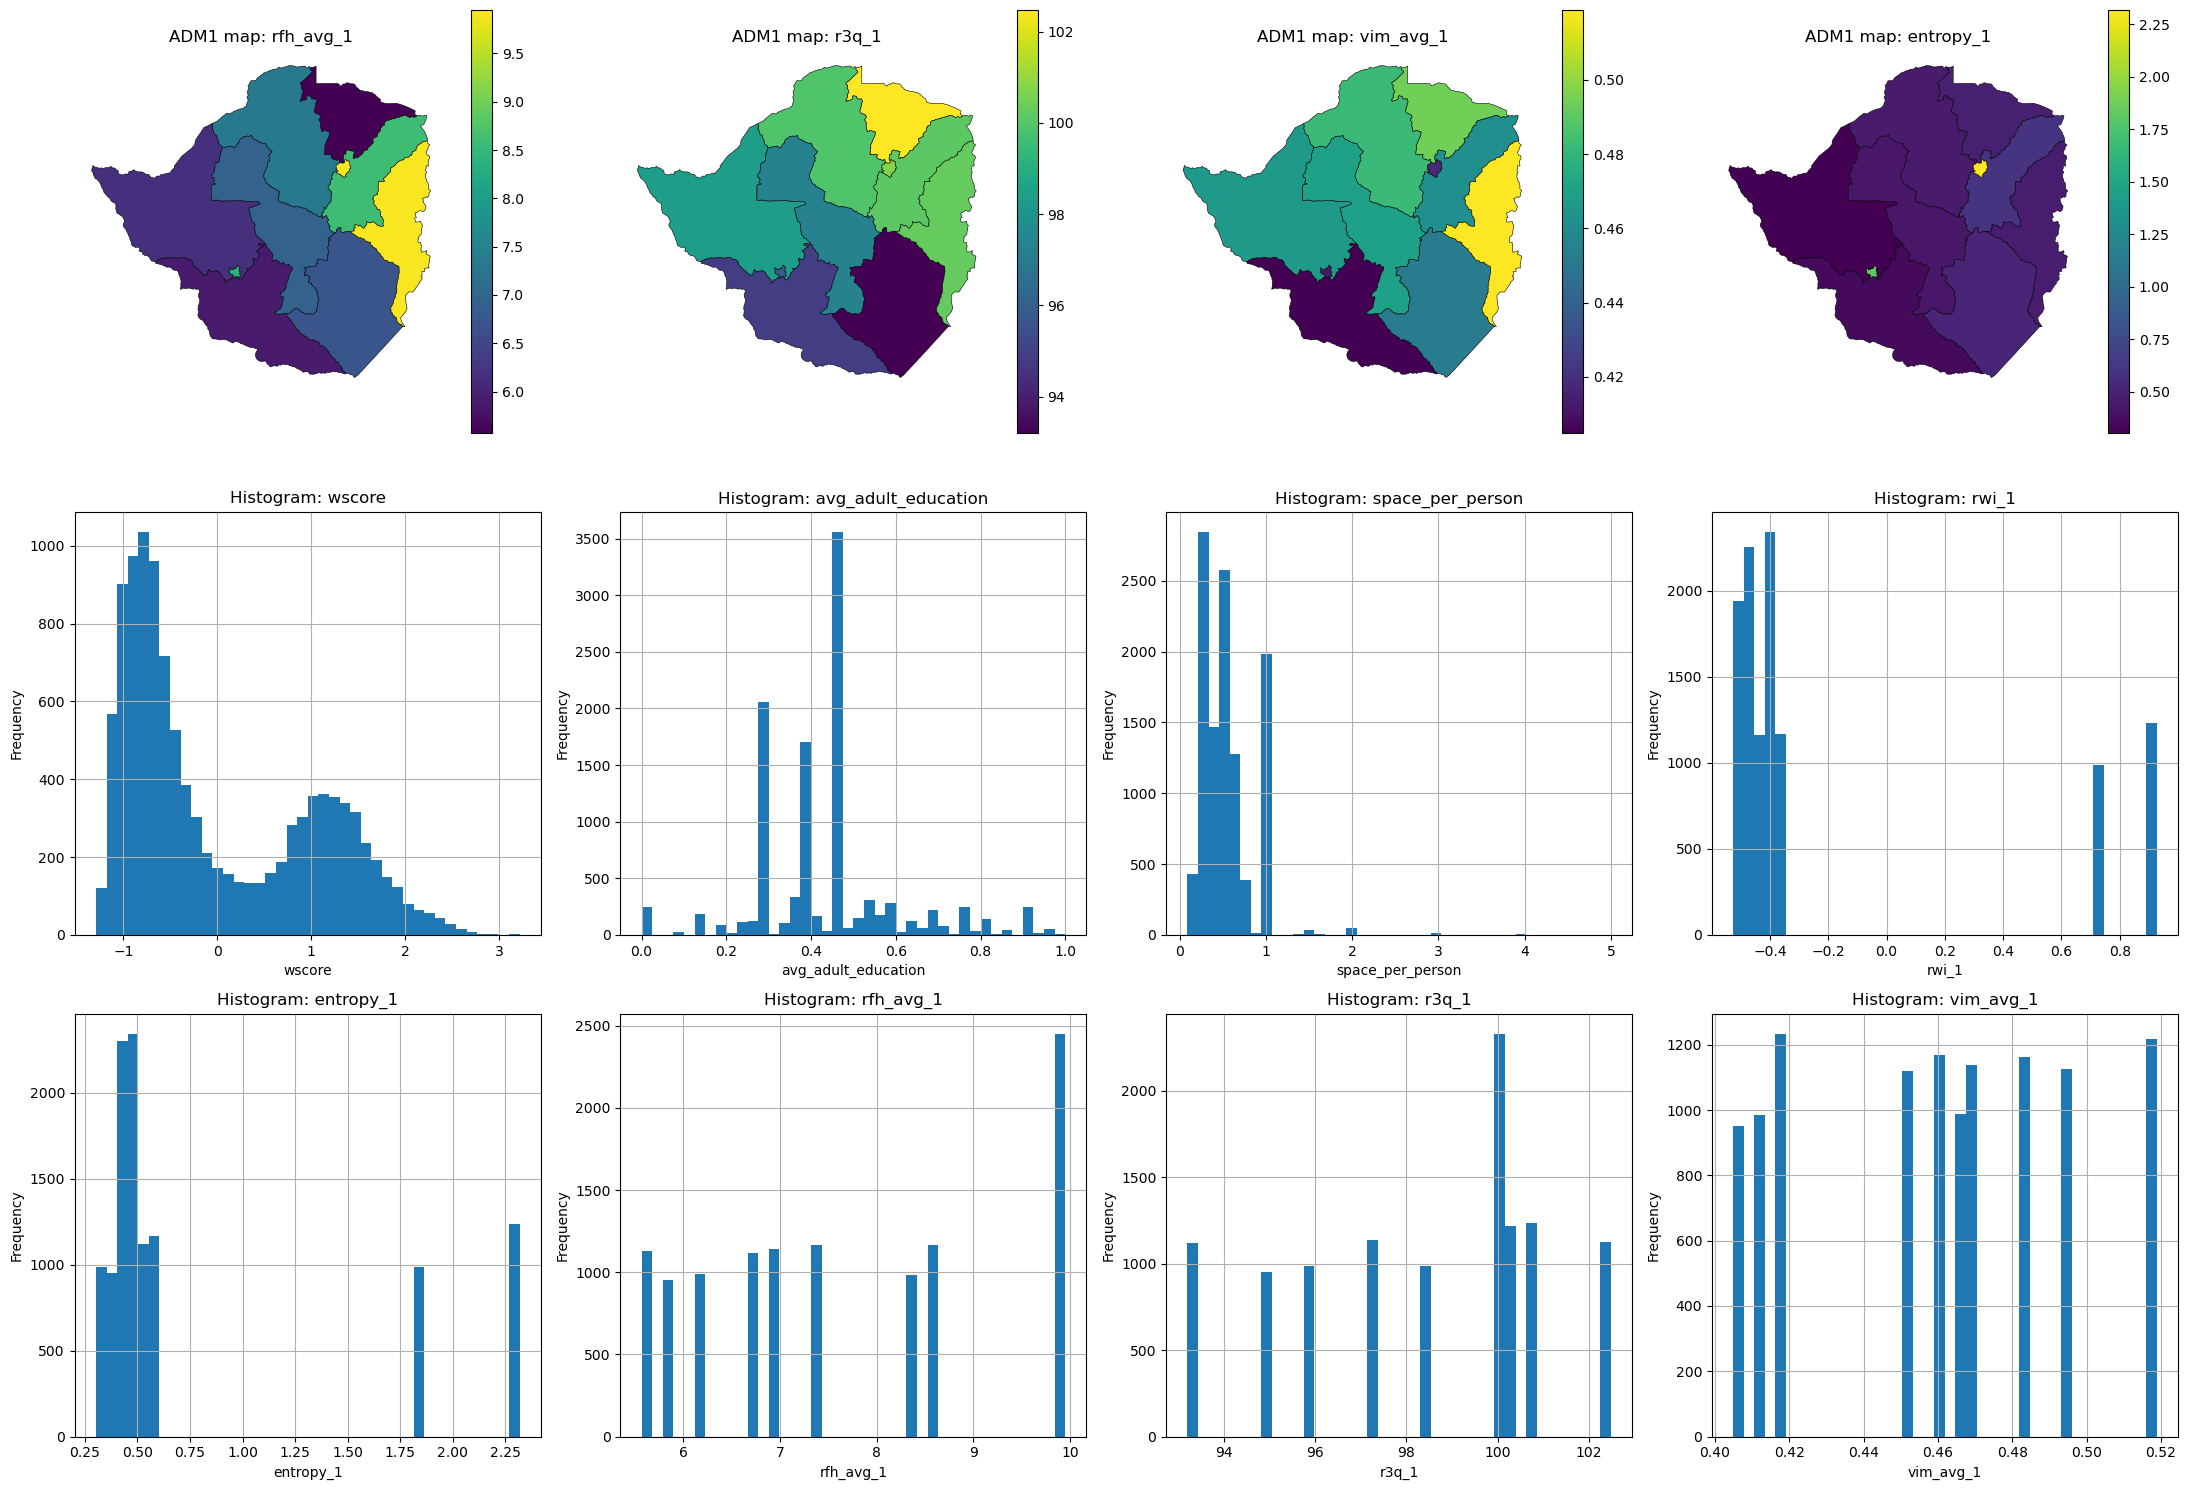

In [21]:
# One unique figure with:
# Row 1: ADM1 maps
# Then histograms below

import matplotlib.pyplot as plt

plot_df = df_final.copy()

# Convert WKT geometries back to shapely geometries if needed.
if "adm1geometry" in plot_df.columns:
    plot_df["adm1geometry"] = plot_df["adm1geometry"].apply(
        lambda x: wkt.loads(x) if isinstance(x, str) else x
    )

adm1_map_vars = [c for c in ["rfh_avg_1", "r3q_1", "vim_avg_1", "entropy_1", "rwi_1"] if c in plot_df.columns]
hist_vars = [
    c for c in [
        "wscore",
        "wscoreMICS",
        "avg_adult_education",
        "space_per_person",
        "rwi_1",
        "entropy_1",
        "rfh_avg_1",
        "r3q_1",
        "vim_avg_1",
    ]
    if c in plot_df.columns
]

adm1_gdf = None
if "adm1geometry" in plot_df.columns and adm1_map_vars:
    adm1_gdf = (
        plot_df[["adm1name", "adm1code", "adm1geometry"] + adm1_map_vars]
        .drop_duplicates(subset=["adm1code"] if "adm1code" in plot_df.columns else ["adm1name"])
        .dropna(subset=["adm1geometry"])
        .copy()
    )
    adm1_gdf = gpd.GeoDataFrame(adm1_gdf, geometry="adm1geometry", crs="EPSG:4326")

n_cols = 4
map_rows = 1 if adm1_gdf is not None and len(adm1_map_vars) > 0 else 0
n_hist_cols = n_cols
n_hist_rows = int(np.ceil(len(hist_vars) / n_hist_cols)) if hist_vars else 0

total_rows = map_rows + n_hist_rows

if total_rows == 0:
    print("No ADM1 maps or histograms available for plotting.")
else:
    fig, axes = plt.subplots(
        total_rows,
        n_cols,
        figsize=(22, 5 * total_rows),
    )

    axes = np.array(axes).reshape(total_rows, n_cols)

    for ax in axes.ravel():
        ax.axis("off")

    current_row = 0

    # Row 1 — ADM1 maps
    if adm1_gdf is not None and len(adm1_map_vars) > 0:
        for i, col in enumerate(adm1_map_vars[:n_cols]):
            ax = axes[current_row, i]
            adm1_gdf.plot(
                column=col,
                ax=ax,
                legend=True,
                edgecolor="black",
                linewidth=0.4,
            )
            ax.set_title(f"ADM1 map: {col}")
            ax.axis("off")

        current_row += 1

    # Histogram rows
    for i, col in enumerate(hist_vars):
        s = pd.to_numeric(plot_df[col], errors="coerce").dropna()
        if len(s) == 0:
            continue

        row = current_row + (i // n_hist_cols)
        col_pos = i % n_hist_cols

        ax = axes[row, col_pos]
        ax.axis("on")

        s.hist(bins=40, ax=ax)
        ax.set_title(f"Histogram: {col}")
        ax.set_xlabel(col)
        ax.set_ylabel("Frequency")

    plt.tight_layout()

    FIG_PATH = BASE_OUT / "maps_and_histograms.png"
    plt.savefig(FIG_PATH, dpi=300, bbox_inches="tight")

    print("Saved figure to:")
    print(FIG_PATH)

    plt.show()